In [1]:
# read the data
import matplotlib.pyplot as plt
import numpy as np
#import pandas as pd
import matplotlib

import mne


raw_file = r"E:\ecf-exp2-notif-mmn\data\Processed\sub002\EEG\sub002_saurabh_NET.vhdr"
raw = mne.io.read_raw_brainvision(raw_file, preload=False)

Extracting parameters from E:\ecf-exp2-notif-mmn\data\Processed\sub002\EEG\sub002_saurabh_NET.vhdr...
Setting channel info structure...


Using matplotlib as 2D backend.


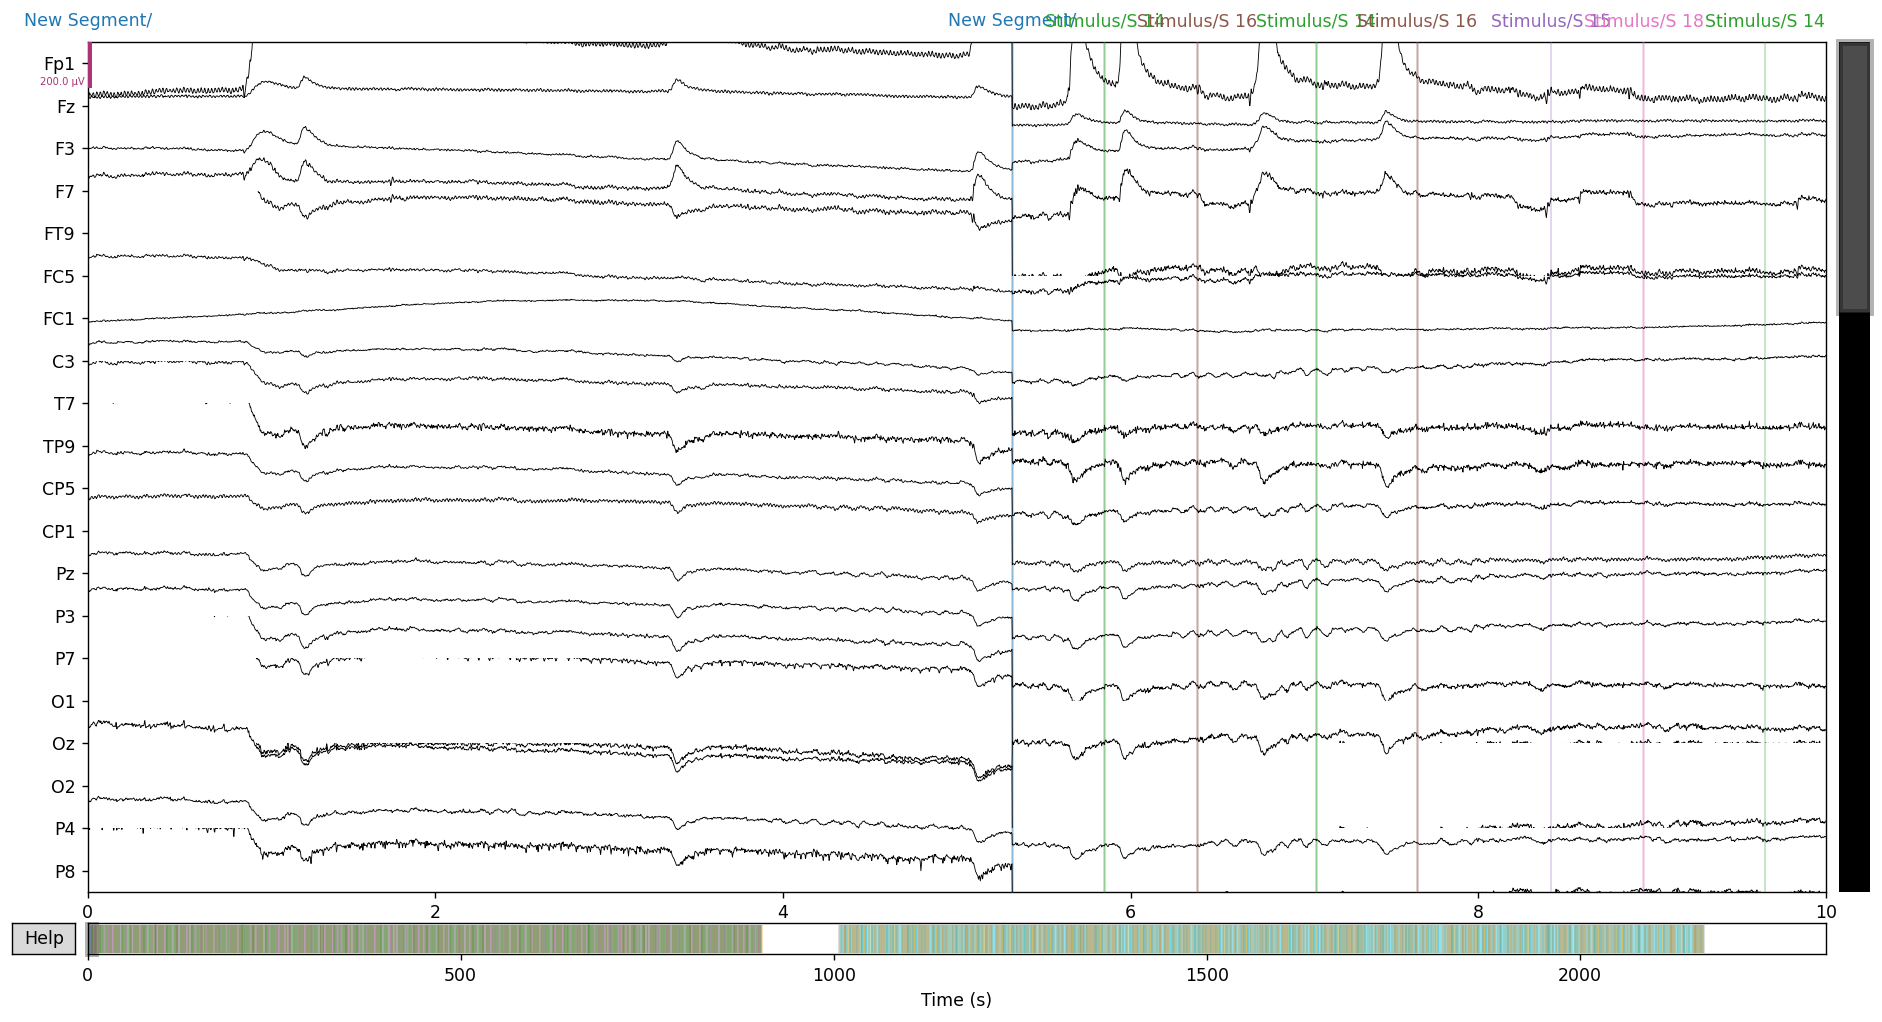

In [2]:
 # it is useful to scroll eeg data 
%matplotlib qt
raw.plot(scalings=dict(eeg=1e-4),clipping='transparent')

In [3]:
#import the channel loaction 
"""builtin_montages = mne.channels.get_builtin_montages(descriptions=True)
for montage_name, montage_description in builtin_montages:
    print(f"{montage_name}: {montage_description}") """
raw.set_montage("easycap-M1")

Measurement date,"May 14, 2024 12:39:45 GMT"
Experimenter,Unknown
Participant,Unknown
Digitized points,66 points
Good channels,63 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,500.00 Hz
Highpass,0.00 Hz
Lowpass,140.00 Hz


Approximating Fpz location by mirroring Oz along the X and Y axes.


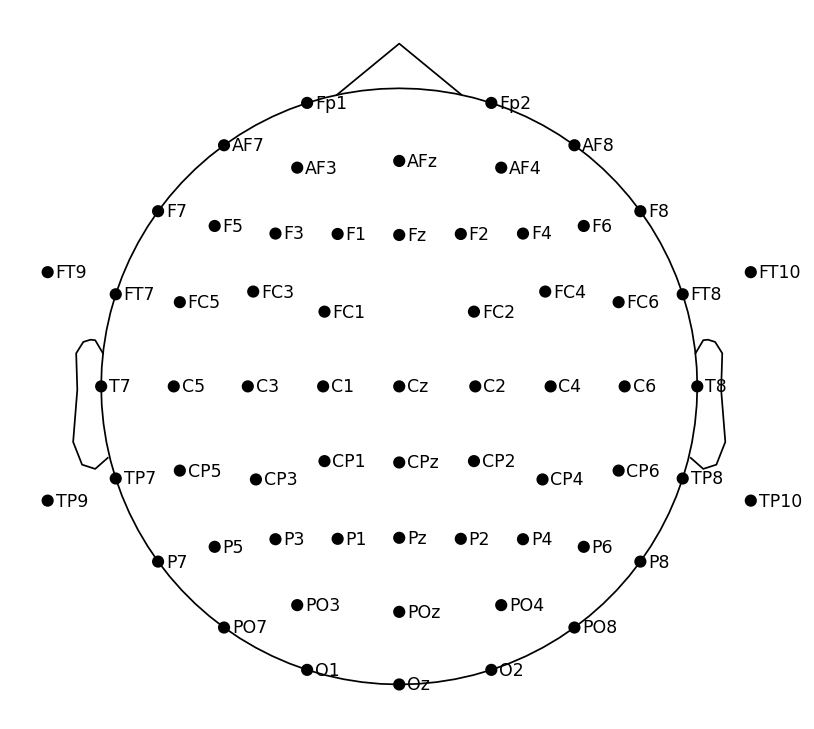

In [4]:

raw.plot_sensors(show_names=True, sphere="eeglab")

Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


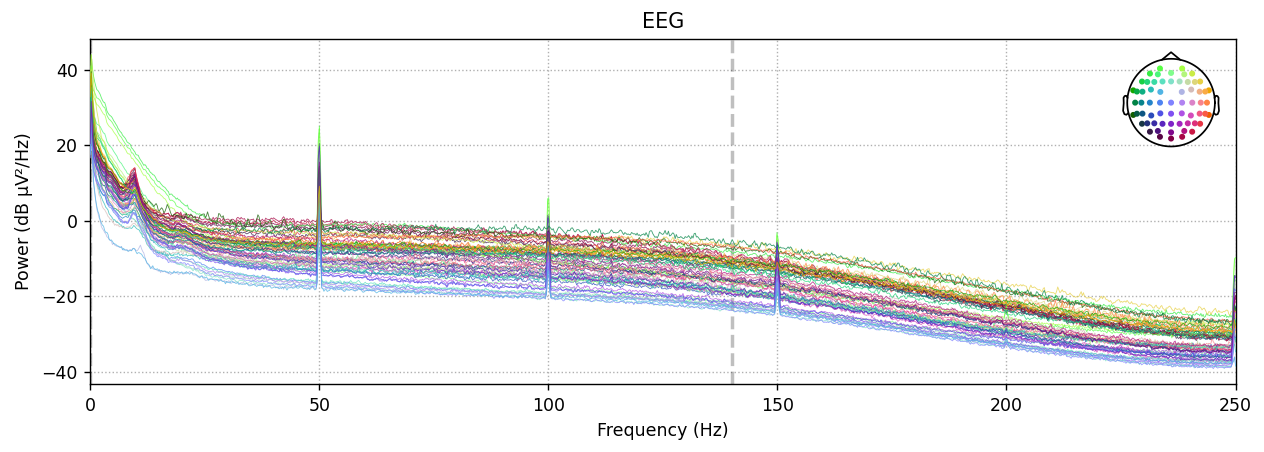

In [5]:
raw.compute_psd().plot(picks="data", amplitude=False)

In [6]:
raw.resample(sfreq=raw.info['sfreq']/2)
raw.info

Measurement date,"May 14, 2024 12:39:45 GMT"
Experimenter,Unknown
Participant,Unknown
Digitized points,66 points
Good channels,63 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,250.00 Hz
Highpass,0.00 Hz
Lowpass,125.00 Hz


Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


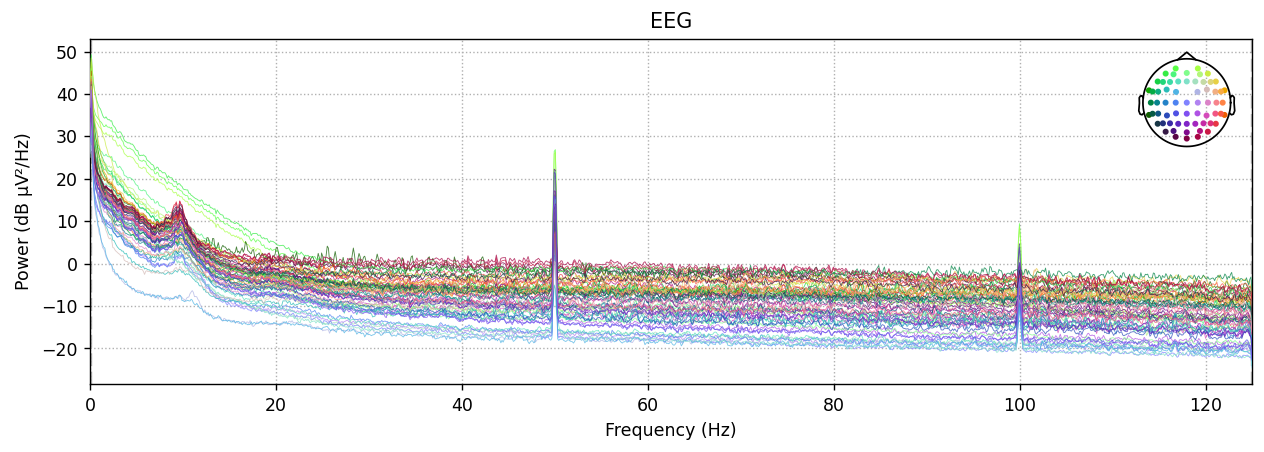

In [7]:
raw.compute_psd().plot(picks="data", amplitude=False)

### Epoching 

In [8]:
#Get the events and its marker
events,event_dict = mne.events_from_annotations(raw)
print(event_dict)

Used Annotations descriptions: ['New Segment/', 'Stimulus/S 11', 'Stimulus/S 14', 'Stimulus/S 15', 'Stimulus/S 16', 'Stimulus/S 18', 'Stimulus/S 21', 'Stimulus/S 24', 'Stimulus/S 25', 'Stimulus/S 26', 'Stimulus/S 28']
{'New Segment/': 99999, 'Stimulus/S 11': 11, 'Stimulus/S 14': 14, 'Stimulus/S 15': 15, 'Stimulus/S 16': 16, 'Stimulus/S 18': 18, 'Stimulus/S 21': 21, 'Stimulus/S 24': 24, 'Stimulus/S 25': 25, 'Stimulus/S 26': 26, 'Stimulus/S 28': 28}


In [9]:
epochs = mne.Epochs(raw, events, event_id=[14,15,24,25], tmin=-0.3, tmax=0.7, preload=True)
fig = epochs.plot(events=events)

Not setting metadata
1599 matching events found
Setting baseline interval to [-0.3, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1599 events and 251 original time points ...
0 bad epochs dropped


C:\Users\CSNDLab\AppData\Local\Temp\ipykernel_4804\3482806344.py:2: RuntimeWarning: More events than default colors available. You should pass a list of unique colors.
  fig = epochs.plot(events=events)


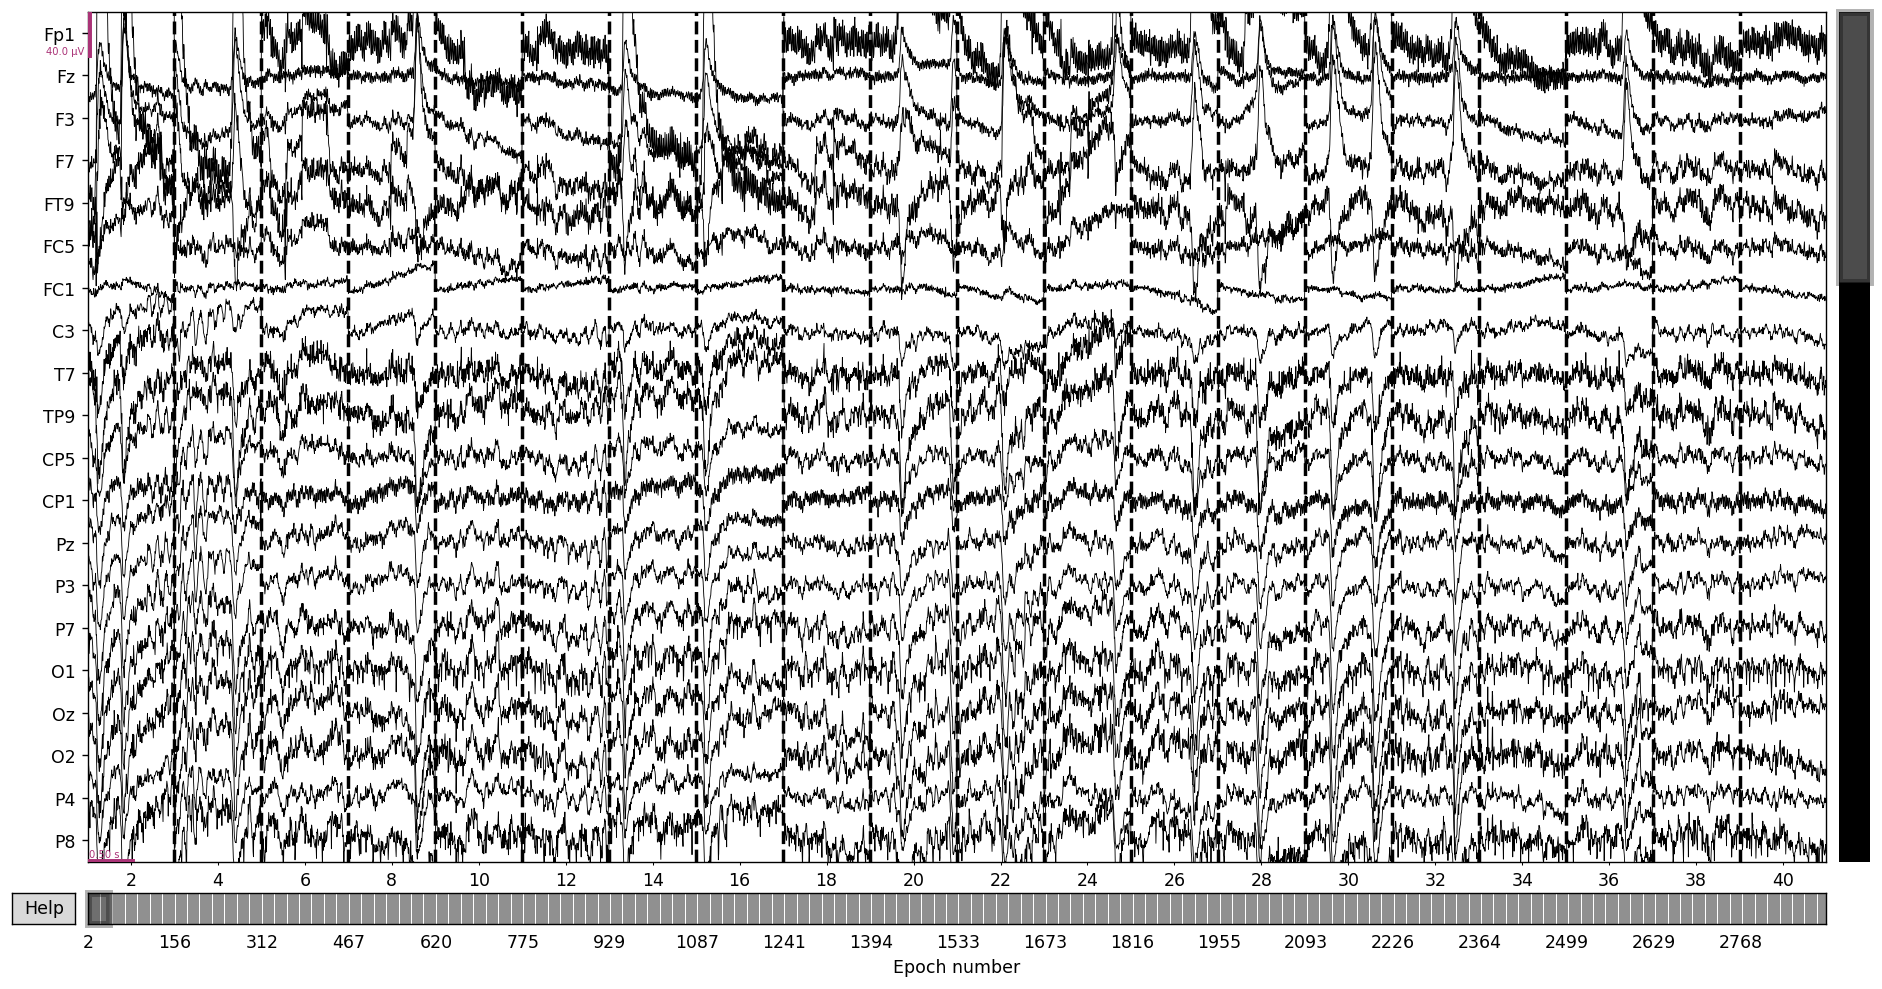

In [10]:
epochs.plot()

In [11]:
print("Total Numner of event in Block 1 :" ,len(epochs['14']),len(epochs['15']))
print("Total Numner of event in Block 2 :" ,len(epochs['24']),len(epochs['25']))

Total Numner of event in Block 1 : 582 117
Total Numner of event in Block 2 : 150 750


In [12]:

baseline_tmin, baseline_tmax = -.3, 0  # None takes the first timepoint

baseline = (baseline_tmin, baseline_tmax)
B1_devi_eps = epochs['15'].average().apply_baseline(baseline)
B1_sta_eps =  epochs["14"].average().apply_baseline(baseline)

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)


In [13]:
# Campare the two contidition of deviant vs standard tone  
evokeds = dict(deviant=B1_devi_eps, standard=B1_sta_eps)
picks = [1,34,35,3,37,36]
mne.viz.plot_compare_evokeds(evokeds, picks=picks, combine="mean")

combining channels using "mean"
combining channels using "mean"


[<Figure size 1000x750 with 1 Axes>]

In [15]:
MMN_erp = mne.combine_evoked([ B1_devi_eps,B1_sta_eps], weights=[-1, 1])
# Campare the two contidition of deviant vs standard tone  
evokeds = dict(deviant=B1_devi_eps, standard=B1_sta_eps,MMN = MMN_erp)
mne.viz.plot_compare_evokeds(evokeds, picks=picks, combine="mean")

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


[<Figure size 1000x750 with 1 Axes>]